Polynomial regression is an extension of linear regression that models the relationship between an independent variable  x and a dependent variable y as an nth-degree polynomial.

It is used for non-linear data.

Why Use It?
    When data shows a curved relationship
    When simple linear regression underfits
    To capture nonlinear patterns without switching to complex models

Important Interview Points
    Is it linear or nonlinear?
    It is linear in parameters, nonlinear in features.

How do you choose degree?
    Using:
    Cross-validation
    Bias–variance tradeoff
    Validation error

    Higher degree → risk of overfitting.

Bias–Variance Tradeoff
    Low degree → High bias (underfitting)
    High degree → High variance (overfitting)
    Optimal degree found via cross-validation

What are disadvantages?
    Overfitting for high degrees
    Poor extrapolation
    Sensitive to outliers

How is it implemented?
   1. By transforming features using polynomial feature expansion using ploynomial regression.
    2. then fitting linear regression. then use linear regession on new data get from loynomial regression.

What It Actually Does
    1. it create new feature using  PolynomialFeatures.
    2, Then we apply a model like: Linear Regression , Logistic Regression, Ridge / Lasso

Text(0, 0.5, 'Y dataset')

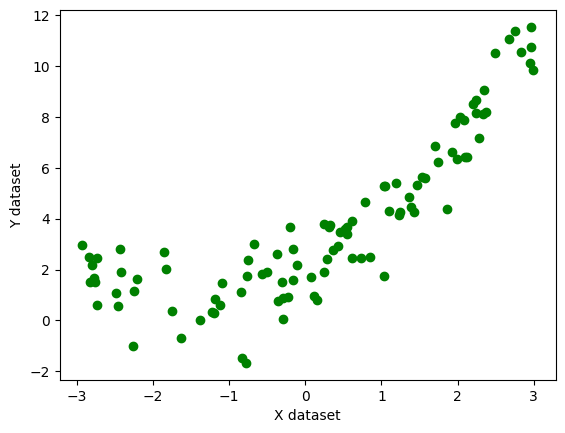

In [2]:
##import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#create data
X = 6 * np.random.rand(100, 1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

0.6621503443734467


Text(0, 0.5, 'Y')

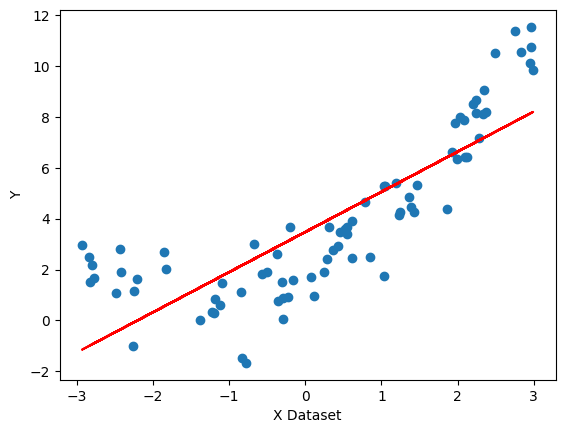

In [5]:
# split data

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


#check with linear regression
## Lets implement Simple Linear Regression

regression_1=LinearRegression()
# train data
regression_1.fit(X_train,y_train)
#check acuracy
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")


### Apply ploy regression

In [ ]:
# first we create new features using ploy regression
from sklearn.preprocessing import PolynomialFeatures

#create poly object using PolynomialFeatures. It is a feature transformation (preprocessing) technique not model.
poly=PolynomialFeatures(degree=2,include_bias=True)
#apply ploy on train data
X_train_poly=poly.fit_transform(X_train)
#aply on test data
X_test_poly=poly.transform(X_test)

X_train_poly, X_test_poly   # we are getting add new features based on degree

(array([[ 1.00000000e+00, -2.98784946e-01,  8.92724441e-02],
        [ 1.00000000e+00, -5.73469568e-01,  3.28867346e-01],
        [ 1.00000000e+00,  1.96470043e+00,  3.86004780e+00],
        [ 1.00000000e+00, -2.24933977e+00,  5.05952941e+00],
        [ 1.00000000e+00,  2.83158929e+00,  8.01789790e+00],
        [ 1.00000000e+00, -8.45747114e-01,  7.15288181e-01],
        [ 1.00000000e+00, -2.82672803e+00,  7.99039137e+00],
        [ 1.00000000e+00,  2.09356580e+00,  4.38301778e+00],
        [ 1.00000000e+00,  2.03472339e+00,  4.14009927e+00],
        [ 1.00000000e+00,  2.96212184e+00,  8.77416580e+00],
        [ 1.00000000e+00,  2.75197905e+00,  7.57338870e+00],
        [ 1.00000000e+00,  2.08851290e+00,  4.36188614e+00],
        [ 1.00000000e+00, -2.91795932e-01,  8.51448660e-02],
        [ 1.00000000e+00,  5.49795325e-01,  3.02274899e-01],
        [ 1.00000000e+00,  2.27857950e+00,  5.19192455e+00],
        [ 1.00000000e+00, -6.76627022e-01,  4.57824127e-01],
        [ 1.00000000e+00

In [ ]:
# apply Regression model on new created features
#create linear model.
regression = LinearRegression()
#fit on new  features.
regression.fit(X_train_poly, y_train)

# predit for new features
y_pred = regression.predict(X_test_poly)
#check accuracy score
score=r2_score(y_test,y_pred)
print(score)   # we can see accuracy get increase.

0.8733887117838934


In [9]:
#check cofficents and intercept
print(regression.coef_)
print(regression.intercept_)

[[0.         1.47921514 0.54378443]]
[1.89253894]


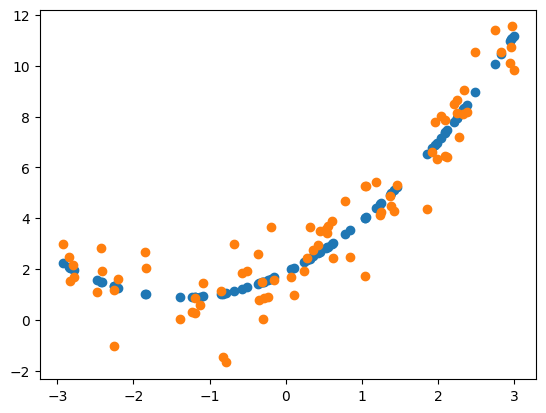

In [10]:
#plot graph again
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

### Use pipline for apply both poly transform and gression model togather

In [11]:
from sklearn.pipeline import Pipeline

def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    #predict output
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()

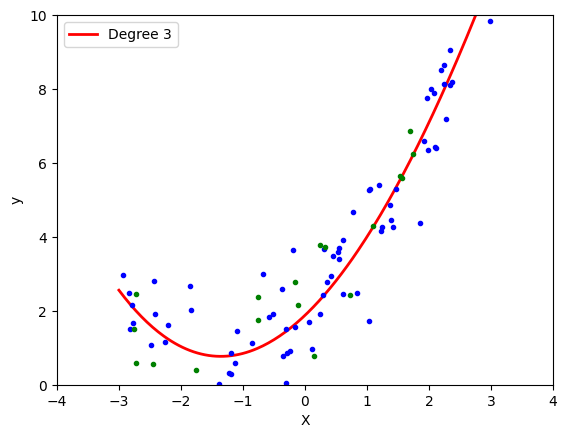

In [13]:
poly_regression(3)